# Additional Analyses (Corrected)

This notebook builds on the preprocessing from Notebook 02 (domain ensemble metalearner).
It assumes that df_mod, the artifacts directory, and all domain/schema JSON files are
already available from running Notebook 02 through the meta-learner step.


Contents:
- A. Temporal Validation (train on 2010-2017, test on 2018-2021)
- B. Domain Ablation Study (drop-one-domain and single-domain meta-learners)
- C. Subgroup and Fairness Analysis
- D. TRIPOD+AI Adherence Checklist

# Prerequisites

Run all cells from Notebook 02 up to and including the meta-learner (B3) cell
before running this notebook. The following objects must be in memory:
- df_mod (the preprocessed dataframe with all features, target, IDs)
- artifacts/domains.json
- artifacts/feature_schema.json
- artifacts/preprocessor_spec.json

In [1]:
# Common imports used throughout this notebook

import json
import numpy as np
import pandas as pd
import joblib
import os
from pathlib import Path

from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    roc_curve, precision_recall_curve
)
from scipy.special import softmax
from lightgbm import LGBMClassifier
import statsmodels.api as sm

Path("artifacts/plots").mkdir(parents=True, exist_ok=True)

In [2]:
df_mod = pd.read_csv("df_mod.csv")

In [23]:
df_mod = df_mod.drop(columns=['Unnamed: 0'], errors="ignore")

In [4]:
unique_names = df_mod['race'].unique()
print(unique_names)

['White' 'Black or African American' 'Unknown' 'white' 'Asian'
 'American Indian or Alaska Native'
 'Native Hawaiian or Other Pacific Islande']


In [5]:
df_mod["race"] = df_mod["race"].replace({"white": "White"})

In [6]:
# Load all saved artifacts from Notebook 02

with open("artifacts/feature_schema.json", "r") as f:
    schema = json.load(f)
with open("artifacts/preprocessor_spec.json", "r") as f:
    spec = json.load(f)
with open("artifacts/domains.json", "r") as f:
    domains = json.load(f)

TARGET = schema["target"]
EXCLUDED = set(schema.get("exclude_cols", []))
ID_COLS = schema.get("id_cols", ["study_id", "study_enc_id", "study_case_id"])

present_cont = spec["present_cont"]
present_cat = spec["present_cat"]
present_bin = spec["present_bin"]

# LGBM base params (same as Notebook 02)
lgbm_params = dict(
    objective="binary",
    boosting_type="gbdt",
    n_estimators=600,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=40,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    n_jobs=-1,
    verbosity=-1,
)

print(f"Target: {TARGET}")
print(f"Domains: {list(domains.keys())}")
print(f"Total rows in df_mod: {len(df_mod)}")

Target: del_1
Domains: ['patient_related', 'surgery_related', 'anesthetics_related']
Total rows in df_mod: 5386


In [7]:
# Helper function: build an unfitted preprocessor restricted to a subset of columns
# This is identical to the one used in Notebook 02

def make_preprocessor(cols_subset):
    cont = [c for c in present_cont if c in cols_subset]
    cat = [c for c in present_cat if c in cols_subset]
    biny = [c for c in present_bin if c in cols_subset]
    try:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse=True)

    cont_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", RobustScaler()),
    ])
    cat_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("ohe", ohe),
    ])
    bin_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
    ])

    return ColumnTransformer(
        transformers=[
            ("cont", cont_pipe, cont),
            ("cat", cat_pipe, cat),
            ("bin", bin_pipe, biny),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )


# CORRECTED: run_domain_ensemble with OOF meta-learner training
# Previously the meta-learner was trained on IN-SAMPLE domain predictions,
# causing calibration leakage. Now it uses OOF predictions within training set.

def run_domain_ensemble(df_train, df_test, domains_dict, target_col, lgbm_kw,
                        n_inner_folds=5):
    """Train domain-specific LGBM on df_train, predict on df_test, then fit and
    evaluate a logistic meta-learner using OOF predictions (not in-sample).

    Steps:
      1. Generate OOF domain predictions within df_train via GroupKFold.
      2. Train the meta-learner on those OOF predictions.
      3. Refit each domain model on the FULL df_train.
      4. Generate test-set domain predictions from the refit models.
      5. Apply the meta-learner to the test-set domain predictions.
    """

    X_cols = [c for c in df_train.columns if c not in EXCLUDED | {target_col}]
    X_train = df_train[X_cols].copy()
    y_train = df_train[target_col].astype(int).values
    X_test = df_test[X_cols].copy()
    y_test = df_test[target_col].astype(int).values
    groups_train = df_train["study_id"].values

    # ── Step 1: OOF domain predictions within training set ──
    oof_domain_preds = {dname: np.zeros(len(y_train)) for dname in domains_dict}
    cv_inner = GroupKFold(n_splits=n_inner_folds)

    for dname, dcols in domains_dict.items():
        dcols_present = [c for c in dcols if c in X_train.columns]
        if len(dcols_present) == 0:
            raise ValueError(f"Domain '{dname}' has no usable columns.")

        for fold_idx, (tr_idx, va_idx) in enumerate(
            cv_inner.split(X_train, y_train, groups=groups_train)
        ):
            X_tr_fold = X_train.iloc[tr_idx][dcols_present]
            y_tr_fold = y_train[tr_idx]
            X_va_fold = X_train.iloc[va_idx][dcols_present]

            prep = make_preprocessor(dcols_present)
            clf = LGBMClassifier(**lgbm_kw)
            pipe = Pipeline(steps=[("prep", prep), ("clf", clf)])
            pipe.fit(X_tr_fold, y_tr_fold)
            oof_domain_preds[dname][va_idx] = pipe.predict_proba(X_va_fold)[:, 1]

    # ── Step 2: Train meta-learner on OOF predictions ──
    meta_X_train_oof = np.column_stack(
        [oof_domain_preds[d] for d in domains_dict]
    )
    meta = LogisticRegression(penalty="l2", C=1.0, solver="lbfgs", max_iter=200)
    meta.fit(meta_X_train_oof, y_train)

    # ── Step 3: Refit domain models on FULL training set ──
    domain_preds_test = {}
    domain_metrics = {}

    for dname, dcols in domains_dict.items():
        dcols_present = [c for c in dcols if c in X_train.columns]
        prep = make_preprocessor(dcols_present)
        clf = LGBMClassifier(**lgbm_kw)
        pipe = Pipeline(steps=[("prep", prep), ("clf", clf)])
        pipe.fit(X_train[dcols_present], y_train)

        p_test = pipe.predict_proba(X_test[dcols_present])[:, 1]
        domain_preds_test[dname] = p_test

        domain_metrics[dname] = {
            "auc": roc_auc_score(y_test, p_test),
            "prauc": average_precision_score(y_test, p_test),
            "brier": brier_score_loss(y_test, p_test),
        }

    # ── Step 4: Apply meta-learner to test-set domain predictions ──
    meta_X_test = np.column_stack(
        [domain_preds_test[d] for d in domains_dict]
    )
    p_meta_test = meta.predict_proba(meta_X_test)[:, 1]

    meta_metrics = {
        "auc": roc_auc_score(y_test, p_meta_test),
        "prauc": average_precision_score(y_test, p_meta_test),
        "brier": brier_score_loss(y_test, p_meta_test),
    }

    coefs = meta.coef_.ravel()
    domain_names = list(domains_dict.keys())
    contributions = softmax(coefs)

    return {
        "domain_metrics": domain_metrics,
        "meta_metrics": meta_metrics,
        "meta_predictions": p_meta_test,
        "y_test": y_test,
        "coefs": dict(zip(domain_names, coefs)),
        "contributions": dict(zip(domain_names, contributions)),
    }

# A. Temporal Validation

Split the cohort by year of procedure: train on 2010-2017, test on 2018-2021.
This addresses the reviewer critique about data age and evaluates whether the
model generalizes to a later time period. We run the full domain ensemble +
meta-learner pipeline on the temporal split.

In [8]:
# Check the distribution of year-proc to pick a reasonable cutoff

print("Year of procedure distribution:")
print(df_mod["year-proc"].value_counts().sort_index())
print(f"\nTotal encounters: {len(df_mod)}")

Year of procedure distribution:
year-proc
2010    175
2011    266
2012    266
2013    284
2014    342
2015    489
2016    678
2017    737
2018    795
2019    667
2020    643
2021     44
Name: count, dtype: int64

Total encounters: 5386


In [9]:
# Temporal split: train on 2010-2017, test on 2018-2021
# Adjust the cutoff year below if the distribution suggests a different split

TEMPORAL_CUTOFF = 2018

df_train_temp = df_mod[df_mod["year-proc"] < TEMPORAL_CUTOFF].copy()
df_test_temp = df_mod[df_mod["year-proc"] >= TEMPORAL_CUTOFF].copy()

print(f"Temporal train (< {TEMPORAL_CUTOFF}): {len(df_train_temp)} encounters")
print(f"  Cases: {df_train_temp[TARGET].sum()}, Controls: {(1 - df_train_temp[TARGET]).sum()}")
print(f"Temporal test (>= {TEMPORAL_CUTOFF}): {len(df_test_temp)} encounters")
print(f"  Cases: {df_test_temp[TARGET].sum()}, Controls: {(1 - df_test_temp[TARGET]).sum()}")

# Check that the test set is large enough to be meaningful
if len(df_test_temp) < 200:
    print("\nWARNING: Test set is small. Consider adjusting TEMPORAL_CUTOFF.")

Temporal train (< 2018): 3237 encounters
  Cases: 1598, Controls: 1639
Temporal test (>= 2018): 2149 encounters
  Cases: 1095, Controls: 1054


In [10]:
# Run the full domain ensemble pipeline on the temporal split

temp_results = run_domain_ensemble(
    df_train=df_train_temp,
    df_test=df_test_temp,
    domains_dict=domains,
    target_col=TARGET,
    lgbm_kw=lgbm_params,
)

print("Temporal validation: domain-level performance on test set")
for dname, m in temp_results["domain_metrics"].items():
    print(f"  {dname:20s}  AUC={m['auc']:.3f}  PR-AUC={m['prauc']:.3f}  Brier={m['brier']:.3f}")

print("\nTemporal validation: meta-learner performance on test set")
m = temp_results["meta_metrics"]
print(f"  AUC={m['auc']:.3f}  PR-AUC={m['prauc']:.3f}  Brier={m['brier']:.3f}")

/home/jupyter-shikshuk/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/jupyter-shikshuk/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/jupyter-shikshuk/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/jupyter-shikshuk/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/jupyter-shikshuk/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fit

Temporal validation: domain-level performance on test set
  patient_related       AUC=0.748  PR-AUC=0.747  Brier=0.208
  surgery_related       AUC=0.896  PR-AUC=0.885  Brier=0.136
  anesthetics_related   AUC=0.738  PR-AUC=0.741  Brier=0.212

Temporal validation: meta-learner performance on test set
  AUC=0.915  PR-AUC=0.902  Brier=0.118


/home/jupyter-shikshuk/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


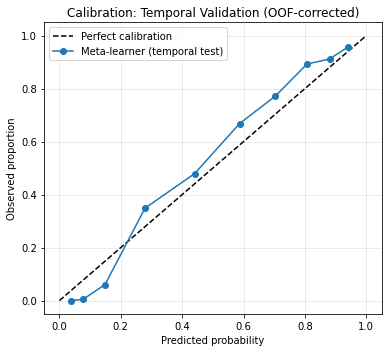

Calibration intercept: 0.139  [0.014, 0.264]
Calibration slope:     1.330  [1.224, 1.437]


In [11]:
# Calibration analysis on the temporal test set (corrected)

import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

y_test_temp = temp_results["y_test"]
p_test_temp = temp_results["meta_predictions"]

# Calibration curve
prob_true, prob_pred = calibration_curve(y_test_temp, p_test_temp, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(1, 1, figsize=(5.5, 5))
ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
ax.plot(prob_pred, prob_true, "o-", label="Meta-learner (temporal test)")
ax.set_xlabel("Predicted probability")
ax.set_ylabel("Observed proportion")
ax.set_title("Calibration: Temporal Validation (OOF-corrected)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("artifacts/plots/calibration_temporal.png", dpi=300)
plt.show()

# Calibration intercept and slope via logistic recalibration (with CIs)
def logit_fn(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))

lp = logit_fn(p_test_temp)
X_cal = sm.add_constant(lp)
cal_model = sm.Logit(y_test_temp, X_cal).fit(disp=False)

cal_intercept = cal_model.params[0]
cal_slope = cal_model.params[1]
ci = cal_model.conf_int()

print(f"Calibration intercept: {cal_intercept:.3f}  "
      f"[{ci[0, 0]:.3f}, {ci[0, 1]:.3f}]")
print(f"Calibration slope:     {cal_slope:.3f}  "
      f"[{ci[1, 0]:.3f}, {ci[1, 1]:.3f}]")

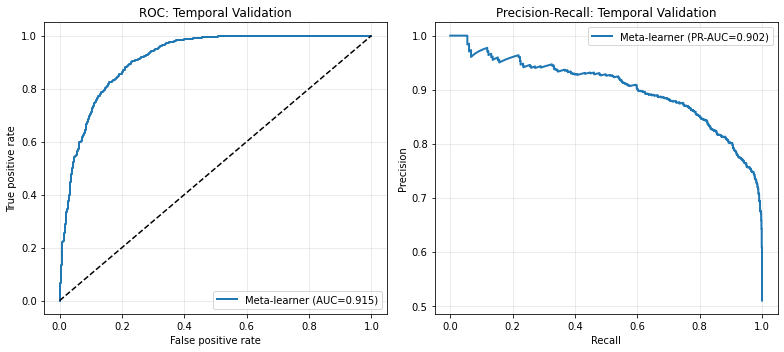

In [12]:
# ROC and PR curves for the temporal test set

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# ROC
fpr, tpr, _ = roc_curve(y_test_temp, p_test_temp)
auc_val = roc_auc_score(y_test_temp, p_test_temp)
axes[0].plot(fpr, tpr, linewidth=2, label=f"Meta-learner (AUC={auc_val:.3f})")
axes[0].plot([0, 1], [0, 1], "k--")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC: Temporal Validation")
axes[0].legend()
axes[0].grid(alpha=0.3)

# PR curve
prec, rec, _ = precision_recall_curve(y_test_temp, p_test_temp)
prauc_val = average_precision_score(y_test_temp, p_test_temp)
axes[1].plot(rec, prec, linewidth=2, label=f"Meta-learner (PR-AUC={prauc_val:.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall: Temporal Validation")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("artifacts/plots/roc_pr_temporal.png", dpi=300)
plt.show()

# B. Domain Ablation Study

Systematically evaluate the contribution of each clinical domain by:
1. Running the meta-learner with each possible 2-domain combination (drop one domain)
2. Running the meta-learner with each domain alone
3. Comparing all combinations against the full 3-domain model

This uses the same patient-grouped 5-fold CV as the original analysis.

In [13]:
# Run the domain ablation study using grouped CV on the full cohort

from itertools import combinations

domain_names = list(domains.keys())
X_cols = [c for c in df_mod.columns if c not in EXCLUDED | {TARGET}]
X = df_mod[X_cols].copy()
y = df_mod[TARGET].astype(int).values
groups = df_mod["study_id"].values

cv = GroupKFold(n_splits=5)

# We will test: all 3-domain combos (the original), all 2-domain combos, and each single domain
ablation_configs = []

# Full model (all 3 domains)
ablation_configs.append(("all_3_domains", domain_names))

# Drop-one-domain (2-domain combinations)
for dropped in domain_names:
    kept = [d for d in domain_names if d != dropped]
    label = f"drop_{dropped}"
    ablation_configs.append((label, kept))

# Single-domain
for single in domain_names:
    label = f"only_{single}"
    ablation_configs.append((label, [single]))

print("Ablation configurations:")
for label, dom_list in ablation_configs:
    print(f"  {label}: {dom_list}")

Ablation configurations:
  all_3_domains: ['patient_related', 'surgery_related', 'anesthetics_related']
  drop_patient_related: ['surgery_related', 'anesthetics_related']
  drop_surgery_related: ['patient_related', 'anesthetics_related']
  drop_anesthetics_related: ['patient_related', 'surgery_related']
  only_patient_related: ['patient_related']
  only_surgery_related: ['surgery_related']
  only_anesthetics_related: ['anesthetics_related']


In [14]:
# Run each ablation configuration

ablation_results = []

for config_label, active_domains in ablation_configs:
    print(f"\nRunning: {config_label} ({active_domains})")

    active_domain_dict = {d: domains[d] for d in active_domains}

    # Store OOF predictions for the meta-learner
    oof_domain = pd.DataFrame(index=df_mod.index, columns=active_domains, dtype=float)
    oof_meta = np.zeros(len(y))

    fold_metrics = []

    for fold_num, (tr_idx, va_idx) in enumerate(cv.split(X, y, groups), start=1):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y[tr_idx], y[va_idx]

        # Train each active domain model
        for dname in active_domains:
            dcols = [c for c in active_domain_dict[dname] if c in X_tr.columns]
            prep = make_preprocessor(dcols)
            clf = LGBMClassifier(**lgbm_params)
            pipe = Pipeline(steps=[("prep", prep), ("clf", clf)])
            pipe.fit(X_tr[dcols], y_tr)
            p_va = pipe.predict_proba(X_va[dcols])[:, 1]
            oof_domain.loc[X_va.index, dname] = p_va

    # Now train the meta-learner using OOF domain predictions
    # Use a second round of GroupKFold so meta-learner is also OOF
    meta_X = oof_domain[active_domains].values.astype(float)

    for fold_num, (tr_idx, va_idx) in enumerate(cv.split(meta_X, y, groups), start=1):
        meta = LogisticRegression(penalty="l2", C=1.0, solver="lbfgs", max_iter=200)
        meta.fit(meta_X[tr_idx], y[tr_idx])
        p_va = meta.predict_proba(meta_X[va_idx])[:, 1]
        oof_meta[va_idx] = p_va

        auc = roc_auc_score(y[va_idx], p_va)
        prauc = average_precision_score(y[va_idx], p_va)
        brier = brier_score_loss(y[va_idx], p_va)
        fold_metrics.append((auc, prauc, brier))

    # Overall OOF metrics
    auc_oof = roc_auc_score(y, oof_meta)
    prauc_oof = average_precision_score(y, oof_meta)
    brier_oof = brier_score_loss(y, oof_meta)

    fold_arr = np.array(fold_metrics)

    ablation_results.append({
        "config": config_label,
        "domains": active_domains,
        "n_domains": len(active_domains),
        "auc_oof": auc_oof,
        "prauc_oof": prauc_oof,
        "brier_oof": brier_oof,
        "auc_mean": fold_arr[:, 0].mean(),
        "auc_sd": fold_arr[:, 0].std(),
        "prauc_mean": fold_arr[:, 1].mean(),
        "prauc_sd": fold_arr[:, 1].std(),
        "brier_mean": fold_arr[:, 2].mean(),
        "brier_sd": fold_arr[:, 2].std(),
    })

    print(f"  OOF: AUC={auc_oof:.3f}  PR-AUC={prauc_oof:.3f}  Brier={brier_oof:.3f}")


Running: all_3_domains (['patient_related', 'surgery_related', 'anesthetics_related'])


/home/jupyter-shikshuk/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/jupyter-shikshuk/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/jupyter-shikshuk/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/jupyter-shikshuk/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/jupyter-shikshuk/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fit

  OOF: AUC=0.899  PR-AUC=0.880  Brier=0.126

Running: drop_patient_related (['surgery_related', 'anesthetics_related'])


/home/jupyter-shikshuk/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/jupyter-shikshuk/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/jupyter-shikshuk/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/jupyter-shikshuk/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/jupyter-shikshuk/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fit

  OOF: AUC=0.883  PR-AUC=0.859  Brier=0.136

Running: drop_surgery_related (['patient_related', 'anesthetics_related'])


...

/home/jupyter-shikshuk/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/jupyter-shikshuk/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/jupyter-shikshuk/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/jupyter-shikshuk/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/jupyter-shikshuk/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fit

  OOF: AUC=0.879  PR-AUC=0.857  Brier=0.140

Running: only_anesthetics_related (['anesthetics_related'])


/home/jupyter-shikshuk/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/jupyter-shikshuk/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/jupyter-shikshuk/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/jupyter-shikshuk/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  OOF: AUC=0.720  PR-AUC=0.718  Brier=0.214


/home/jupyter-shikshuk/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [15]:
# Summarize ablation results in a clean table

ablation_df = pd.DataFrame(ablation_results)
ablation_df = ablation_df.sort_values("auc_oof", ascending=False).reset_index(drop=True)

display_cols = ["config", "n_domains", "auc_oof", "prauc_oof", "brier_oof",
                "auc_mean", "auc_sd"]
print("Domain Ablation Study Results (sorted by OOF AUC):")
display(ablation_df[display_cols])

ablation_df.to_csv("artifacts/ablation_results.csv", index=False)
print("\nSaved to artifacts/ablation_results.csv")

Domain Ablation Study Results (sorted by OOF AUC):


,config,n_domains,auc_oof,prauc_oof,brier_oof,auc_mean,auc_sd
0,all_3_domains,3,0.898654,0.880332,0.126255,0.898916,0.004482
1,drop_anesthetics_related,2,0.897568,0.881208,0.127533,0.897768,0.005801
2,drop_patient_related,2,0.883017,0.858863,0.136008,0.883240,0.008235
3,only_surgery_related,1,0.878674,0.857469,0.139549,0.878988,0.010140
4,drop_surgery_related,2,0.778863,0.766907,0.191692,0.779077,0.011453
5,only_patient_related,1,0.733760,0.725292,0.209113,0.733921,0.017423
6,only_anesthetics_related,1,0.719875,0.717632,0.213844,0.720222,0.008570



Saved to artifacts/ablation_results.csv


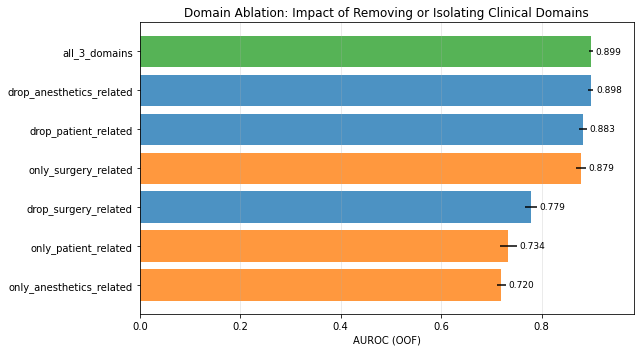

In [16]:
# Visualize the ablation results

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))

configs = ablation_df["config"].values
aucs = ablation_df["auc_oof"].values
auc_sds = ablation_df["auc_sd"].values

colors = []
for _, row in ablation_df.iterrows():
    if row["n_domains"] == 3:
        colors.append("#2ca02c")
    elif row["n_domains"] == 2:
        colors.append("#1f77b4")
    else:
        colors.append("#ff7f0e")

bars = ax.barh(range(len(configs)), aucs, xerr=auc_sds, color=colors, alpha=0.8)
ax.set_yticks(range(len(configs)))
ax.set_yticklabels(configs)
ax.set_xlabel("AUROC (OOF)")
ax.set_title("Domain Ablation: Impact of Removing or Isolating Clinical Domains")
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)

# Add value labels
for i, (v, sd) in enumerate(zip(aucs, auc_sds)):
    ax.text(v + sd + 0.005, i, f"{v:.3f}", va="center", fontsize=9)
ax.set_xlim(0, max(aucs + auc_sds) + 0.08)

plt.tight_layout()
plt.savefig("artifacts/plots/ablation_barplot.png", dpi=300)
plt.show()

# C. Subgroup and Fairness Analysis

Evaluate the meta-learner performance across clinically relevant subgroups:
age groups, sex, race, and surgical specialty. This uses the OOF meta-learner
predictions from Notebook 02.

In [17]:
# Load the OOF meta predictions from Notebook 02

oof_meta_probs = pd.read_parquet("artifacts/oof_meta_probs.parquet")["meta_oof_prob"].values
y_full = df_mod[TARGET].astype(int).values

print(f"Loaded {len(oof_meta_probs)} OOF meta predictions")
print(f"Overall OOF AUC: {roc_auc_score(y_full, oof_meta_probs):.3f}")

Loaded 5386 OOF meta predictions
Overall OOF AUC: 0.899


In [18]:
# Define subgroup columns and how to bin them

# Age groups
df_mod["age_group"] = pd.cut(
    df_mod["age"],
    bins=[0, 50, 65, 75, 200],
    labels=["<50", "50-64", "65-75", ">75"],
    right=False,
)

# Surgical specialty (pick the one-hot column that is 1 for each encounter)
surg_cols = ["General Surgery", "Vascular", "Orthopedics", "Thoracic",
             "Neurosurgery", "GYN", "GU", "ENT", "EYE", "NORA"]
existing_surg = [c for c in surg_cols if c in df_mod.columns]

def get_specialty(row):
    for c in existing_surg:
        if row.get(c, 0) == 1:
            return c
    return "Other"

df_mod["specialty"] = df_mod.apply(get_specialty, axis=1)

print("Age group distribution:")
print(df_mod["age_group"].value_counts().sort_index())
print("\nSex distribution:")
print(df_mod["sex"].value_counts())
print("\nRace distribution:")
print(df_mod["race"].value_counts())
print("\nSpecialty distribution:")
print(df_mod["specialty"].value_counts())

Age group distribution:
age_group
<50      1124
50-64    1488
65-75    1354
>75      1420
Name: count, dtype: int64

Sex distribution:
sex
M    2780
F    2606
Name: count, dtype: int64

Race distribution:
race
White                                       4784
Black or African American                    518
Unknown                                       44
Asian                                         32
American Indian or Alaska Native               4
Native Hawaiian or Other Pacific Islande       4
Name: count, dtype: int64

Specialty distribution:
specialty
Orthopedics        1231
General Surgery     979
NORA                839
Neurosurgery        632
GU                  524
Vascular            332
EYE                 277
ENT                 222
Thoracic            218
GYN                 132
Name: count, dtype: int64


In [19]:
# Compute AUC for each subgroup

def subgroup_metrics(group_col, group_label):
    """Compute AUC, PR-AUC, Brier, and N for each value of group_col."""
    results = []
    for grp_val, grp_idx in df_mod.groupby(group_col).groups.items():
        y_grp = y_full[grp_idx]
        p_grp = oof_meta_probs[grp_idx]
        n = len(y_grp)
        n_cases = int(y_grp.sum())

        # Need at least 2 classes and a reasonable sample for AUC
        if n_cases < 5 or (n - n_cases) < 5:
            results.append({
                "group_type": group_label,
                "subgroup": str(grp_val),
                "n": n,
                "n_cases": n_cases,
                "prevalence": n_cases / n,
                "auc": np.nan,
                "prauc": np.nan,
                "brier": np.nan,
            })
            continue

        auc = roc_auc_score(y_grp, p_grp)
        prauc = average_precision_score(y_grp, p_grp)
        brier = brier_score_loss(y_grp, p_grp)

        results.append({
            "group_type": group_label,
            "subgroup": str(grp_val),
            "n": n,
            "n_cases": n_cases,
            "prevalence": n_cases / n,
            "auc": auc,
            "prauc": prauc,
            "brier": brier,
        })

    return pd.DataFrame(results)


sg_age = subgroup_metrics("age_group", "Age group")
sg_sex = subgroup_metrics("sex", "Sex")
sg_race = subgroup_metrics("race", "Race")
sg_spec = subgroup_metrics("specialty", "Surgical specialty")

subgroup_all = pd.concat([sg_age, sg_sex, sg_race, sg_spec], ignore_index=True)

print("Subgroup performance summary:")
display(subgroup_all)

subgroup_all.to_csv("artifacts/subgroup_fairness.csv", index=False)
print("\nSaved to artifacts/subgroup_fairness.csv")

Subgroup performance summary:


/tmp/ipykernel_3095844/787947459.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for grp_val, grp_idx in df_mod.groupby(group_col).groups.items():


,group_type,subgroup,n,n_cases,prevalence,auc,prauc,brier
0,Age group,<50,1124,562,0.500000,0.915873,0.903979,0.114248
1,Age group,50-64,1488,744,0.500000,0.890088,0.868205,0.131512
2,Age group,65-75,1354,677,0.500000,0.919569,0.908212,0.112914
3,Age group,>75,1420,710,0.500000,0.871690,0.843284,0.142362
4,Sex,F,2606,1303,0.500000,0.896674,0.879883,0.127880
5,Sex,M,2780,1390,0.500000,0.901204,0.882167,0.124420
6,Race,American Indian or Alaska Native,4,2,0.500000,NaN,NaN,NaN
7,Race,Asian,32,16,0.500000,0.898438,0.892923,0.118015
8,Race,Black or African American,518,259,0.500000,0.881233,0.864618,0.139446
9,Race,Native Hawaiian or Other Pacific Islande,4,2,0.500000,NaN,NaN,NaN



Saved to artifacts/subgroup_fairness.csv


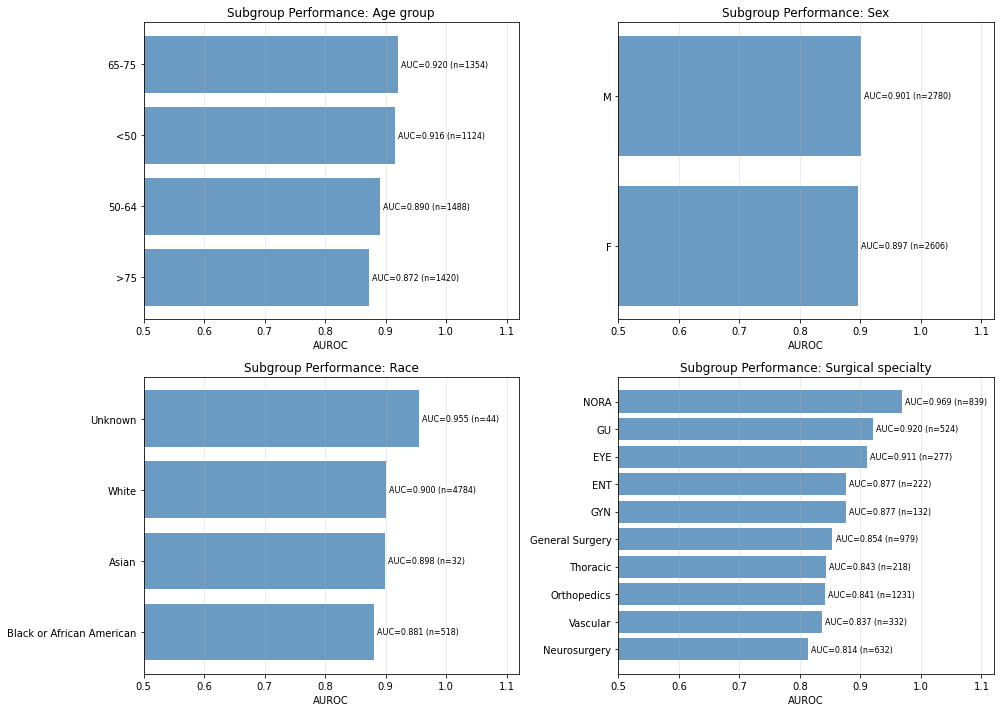

In [20]:
# Visualize subgroup AUCs as grouped bar charts

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (group_label, sg_df) in zip(
    axes.ravel(),
    [("Age group", sg_age), ("Sex", sg_sex), ("Race", sg_race), ("Surgical specialty", sg_spec)],
):
    sg_plot = sg_df.dropna(subset=["auc"]).copy()
    if len(sg_plot) == 0:
        ax.set_title(f"{group_label} (no data)")
        continue

    sg_plot = sg_plot.sort_values("auc", ascending=True)
    bars = ax.barh(sg_plot["subgroup"], sg_plot["auc"], color="steelblue", alpha=0.8)

    # Add N labels
    for i, (_, row) in enumerate(sg_plot.iterrows()):
        ax.text(row["auc"] + 0.005, i, f"AUC={row['auc']:.3f} (n={row['n']})",
                va="center", fontsize=8)

    ax.set_xlabel("AUROC")
    ax.set_title(f"Subgroup Performance: {group_label}")
    ax.set_xlim(0.5, 1.12)
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("artifacts/plots/subgroup_fairness.png", dpi=300)
plt.show()

In [21]:
# Compute the fairness gap: max AUC difference across subgroups within each category

for group_label in ["Age group", "Sex", "Race", "Surgical specialty"]:
    sg = subgroup_all[subgroup_all["group_type"] == group_label].dropna(subset=["auc"])
    if len(sg) < 2:
        continue
    auc_min = sg["auc"].min()
    auc_max = sg["auc"].max()
    gap = auc_max - auc_min
    print(f"{group_label}: AUC range [{auc_min:.3f}, {auc_max:.3f}], gap = {gap:.3f}")

Age group: AUC range [0.872, 0.920], gap = 0.048
Sex: AUC range [0.897, 0.901], gap = 0.005
Race: AUC range [0.881, 0.955], gap = 0.073
Surgical specialty: AUC range [0.814, 0.969], gap = 0.155


# D. TRIPOD+AI Adherence Checklist

Generate a TRIPOD+AI checklist table for the supplementary material.
This follows the 2024 TRIPOD+AI statement (Collins et al., BMJ 2024;385:e078378).
Fill in the "Reported" column with the relevant page/section in the manuscript.

In [22]:
# TRIPOD+AI checklist items (abbreviated)
# The "Status" column is pre-filled based on what our study actually does.
# "Location" should be updated with manuscript page/section numbers.

tripod_items = [
    ("1", "Title", "Identify as prediction model study; specify target population and outcome", "Yes", ""),
    ("2", "Abstract", "Structured summary with study design, methods, results, conclusions", "Yes", ""),
    ("3a", "Background", "Explain clinical context and rationale", "Yes", ""),
    ("3b", "Objectives", "Specify study objectives including model development and validation", "Yes", ""),
    ("4a", "Source of data", "Describe study design and data source", "Yes", "Methods"),
    ("4b", "Dates", "Specify dates of accrual, follow-up, data extraction", "Yes", "Methods"),
    ("5a", "Participants", "Eligibility criteria for participants", "Yes", "Methods"),
    ("5b", "Study setting", "Describe the study setting", "Yes", "Methods"),
    ("6a", "Outcome", "Define outcome with timing of assessment", "Yes", "Methods"),
    ("6b", "Blinding", "Whether outcome assessment was blinded to predictors", "Partial", "Retrospective design"),
    ("7a", "Predictors", "Define all candidate predictors and timing of measurement", "Yes", "Methods + Appendix 2"),
    ("7b", "Predictor handling", "Report handling of predictors in the analysis", "Yes", "Methods"),
    ("8", "Sample size", "Explain how study size was determined", "Yes", "Methods + Appendix 3"),
    ("9", "Missing data", "Describe how missing data were handled", "Yes", "Methods"),
    ("10a", "Statistical methods", "Describe model building and selection of predictors", "Yes", "Methods + Appendix 4"),
    ("10b", "Model performance", "Specify measures to evaluate model performance", "Yes", "Methods"),
    ("10c", "Model updating", "Describe any model updating", "N/A", "Development only"),
    ("10d", "Risk groups", "Report any grouping of predicted probabilities", "Yes", "DCA thresholds"),
    ("10e", "Validation", "Type of internal validation", "Yes", "Grouped CV + temporal"),
    ("11", "Participants", "Report numbers at each stage (flow diagram)", "Yes", "Results"),
    ("12", "Model development", "Present final model with coefficients or equivalent", "Yes", "Results + Appendix 4"),
    ("13a", "Performance: discrimination", "Report discrimination measures with confidence", "Yes", "Results"),
    ("13b", "Performance: calibration", "Report calibration measures", "Yes", "Results + Appendix 8"),
    ("14", "Model updating", "Report results from model updating", "N/A", ""),
    ("15a", "Interpretation", "Interpret results considering objectives and limitations", "Yes", "Discussion"),
    ("15b", "Implications", "Discuss potential clinical use and next steps", "Yes", "Discussion"),
    ("16", "Limitations", "Discuss limitations of the study", "Yes", "Discussion"),
    ("17", "Supplementary", "Provide information about availability of code and data", "Yes", "Appendix 9"),
    ("18", "Funding", "Report sources of funding", "Yes", "Funding section"),
    # AI-specific items
    ("AI-1", "AI: Software", "Report software, libraries, and versions used", "Yes", "Methods"),
    ("AI-2", "AI: Hyperparameters", "Report hyperparameter tuning and selection procedure", "Yes", "Methods + Appendix 4"),
    ("AI-3", "AI: Feature importance", "Report approach to model interpretability", "Yes", "SHAP analysis"),
    ("AI-4", "AI: Fairness", "Assess performance across demographic subgroups", "Yes", "Subgroup analysis"),
]

tripod_df = pd.DataFrame(tripod_items, columns=["Item", "Section", "Description", "Status", "Location"])

print("TRIPOD+AI Adherence Checklist:")
display(tripod_df)

tripod_df.to_csv("artifacts/tripod_ai_checklist.csv", index=False)
print("\nSaved to artifacts/tripod_ai_checklist.csv")

TRIPOD+AI Adherence Checklist:


,Item,Section,Description,Status,Location
0,1,Title,Identify as prediction model study; specify ta...,Yes,
1,2,Abstract,"Structured summary with study design, methods,...",Yes,
2,3a,Background,Explain clinical context and rationale,Yes,
3,3b,Objectives,Specify study objectives including model devel...,Yes,
4,4a,Source of data,Describe study design and data source,Yes,Methods
5,4b,Dates,"Specify dates of accrual, follow-up, data extr...",Yes,Methods
6,5a,Participants,Eligibility criteria for participants,Yes,Methods
7,5b,Study setting,Describe the study setting,Yes,Methods
8,6a,Outcome,Define outcome with timing of assessment,Yes,Methods
9,6b,Blinding,Whether outcome assessment was blinded to pred...,Partial,Retrospective design



Saved to artifacts/tripod_ai_checklist.csv


# Summary of All Additional Analyses

A. Temporal Validation: full domain ensemble + meta-learner trained on pre-2018
   data, tested on 2018-2021 data, with calibration and ROC/PR curves.

B. Domain Ablation: 7 configurations (full 3-domain, three 2-domain drop-one,
   three single-domain) evaluated via grouped 5-fold CV.

C. Subgroup Fairness: AUC, PR-AUC, Brier stratified by age group, sex, race,
   and surgical specialty; fairness gap quantified.

D. TRIPOD+AI Checklist: comprehensive adherence table for supplementary material.

In [ ]:
# End of Notebook